# Psi-X Mixture Data Loader

-- adapted from GR00T/DreamZero's repo, and supports 

+ All preivous Psi0 lerobot dataset (SIMPLE, Psi0 Real)

+ DreamZero-format data loading (chunkwise data loading to train WAM)

+ Dataset sharding for parallel training (with A/B caching)

+ Mixture dataset training (with weighted sampling at trajectory level)

+ Per-dataset statistics

+ Static type hinting





Change to project root directory

In [1]:
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

%cd {project_root}

/hfm/songlin/psi0


/hfm/songlin/psi0/.venv-psi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


> Make sure you created `.env` and set `PSI_HOME` environment variable
> 
> The code below assume `PSI_HOME` exists and files will be put under this folder by convention

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
! echo $PSI_HOME

/hfm


In [4]:
PSI_HOME=os.environ.get("PSI_HOME")
print(f"PSI_HOME: {PSI_HOME}")

PSI_HOME: /hfm


In [5]:
from psi.config.train.finetune_real_psix_config import DynamicDataConfig

/hfm/songlin/psi0/.venv-psi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import tyro
from transformers import AutoProcessor

In [7]:
vlm_processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen3-VL-2B-Instruct", trust_remote_code=True
)

In [8]:
data_cfg = tyro.cli(DynamicDataConfig, config=(tyro.conf.ConsolidateSubcommandArgs,), args=[
    "--dataset_paths", "simple_g1:/hfm/data/simple/G1WholebodyBendPickMP-v0",
    "--transform.repack.simple.pad-action-dim=36",
    "--transform.repack.simple.pad-state-dim=36",
    "--transform.repack.simple.action_chunk_size=30",
    "--transform.model.resize.size", "270", "480",
    "--transform.model.center_crop.size", "270", "480"
])

In [9]:
mixture_dataset = data_cfg(split="val", transform_kwargs={
    "vlm_processor": vlm_processor
})

Initializing datasets: 100%|██████████| 1/1 [00:00<00:00, 78.38it/s]


## Dataset Lengths

Note: the default `__len__` is inaccurate. It's a rough estimation based on `shard_size` and `shard_sampling_rate`.

In [10]:
print(len(mixture_dataset.raw_dataset))

16000


The real dataset length is only obtained by iterate all the datasets and sum their real shard lengths:

In [11]:
sum(len(ds) for ds in mixture_dataset.raw_dataset.datasets)

15509

## Shards

We can also read the shards across different datasets `(dataset_idx, shard_idx)`

In [12]:
mixture_dataset.raw_dataset.all_shards

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7)]

## Data Loading

In [15]:
eps_idx = None
all_images = []
all_actions = []
for frame in mixture_dataset:
    if eps_idx is None:
        eps_idx = frame["episode_index"]
    
    if eps_idx != frame["episode_index"]:
        break

    all_images.append(frame["observations"][0])
    all_actions.append(frame["actions"])

[00:46:09 06/08] INFO     | >> rk=0, wk=0: waited 2.07 sec for shard 0 (ds=0)               ]8;id=134802;file:///hfm/songlin/psi0/src/psi/data/gear/dataset/lerobot_sharded.py\lerobot_sharded.py]8;;\:]8;id=643152;file:///hfm/songlin/psi0/src/psi/data/gear/dataset/lerobot_sharded.py#1467\1467]8;;\

In [16]:
print(len(all_images))

155


In [28]:
from psi.utils import make_image_grid #, pt_to_pil
from PIL import Image

In [23]:
type(all_images[0]), len(all_images), all_images[0].shape, all_images[0].max(), all_images[0].min()

(torch.Tensor,
 155,
 torch.Size([3, 180, 320]),
 tensor(255, dtype=torch.uint8),
 tensor(0, dtype=torch.uint8))

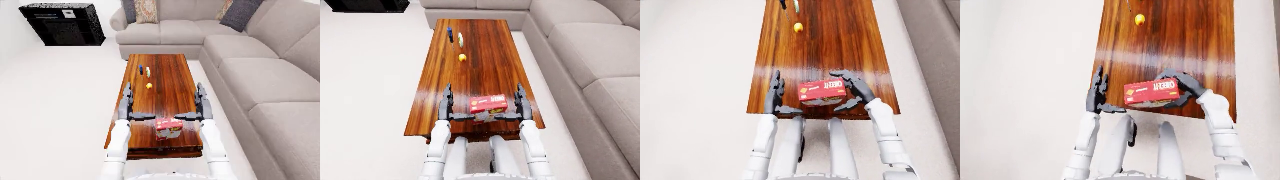

In [33]:
make_image_grid(
    [Image.fromarray(img.numpy().transpose(1, 2, 0)) for img in all_images[0:155:51]],
    nrows=1,
)

## Check Padding

In [34]:
import torch

In [35]:
T = len(all_actions)

In [36]:
all_actions = torch.stack(all_actions, dim=0) # (T, Tp, Da)

Actions should be consistent across timesteps.

In [37]:
a_prev = all_actions[0]
for i in range(1, T):
    a_curr = all_actions[i]
    torch.allclose(a_prev[:-1], a_curr[:1])
    

Plot line charts for each of the 36 dimension across timesteps: all_actions[T,0,i], $i \in [0,36]$

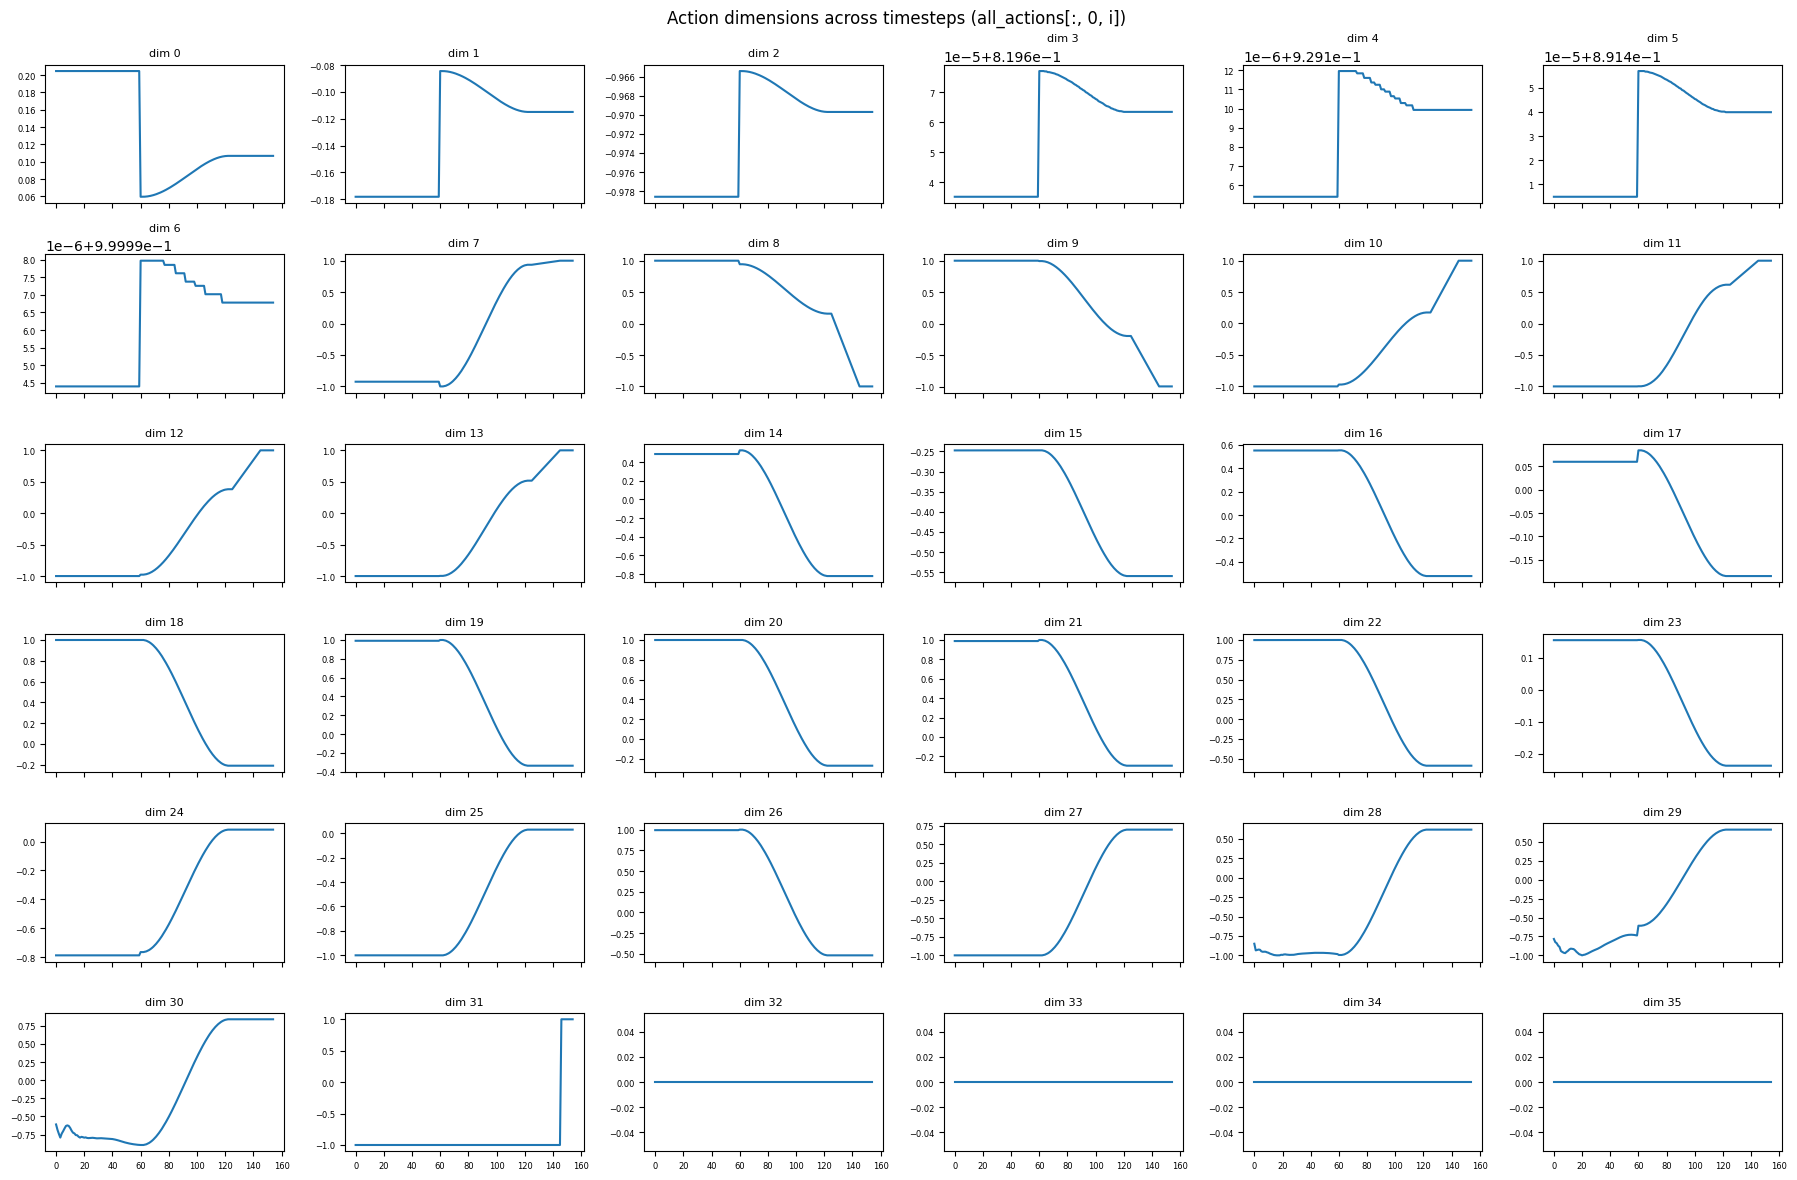

In [38]:
import matplotlib.pyplot as plt
import numpy as np

data = all_actions[:, 0, :].numpy()  # (T, 36)
timesteps = np.arange(T)

fig, axes = plt.subplots(6, 6, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for i in range(36):
    axes[i].plot(timesteps, data[:, i])
    axes[i].set_title(f"dim {i}", fontsize=8)
    axes[i].tick_params(labelsize=6)

for ax in axes[36:]:
    ax.set_visible(False)

fig.suptitle("Action dimensions across timesteps (all_actions[:, 0, i])", fontsize=12)
plt.tight_layout()
plt.show()

Check last action padding (absolute vs relative)

In [39]:
last_action = all_actions[-1][0]

In [40]:
print(last_action)

tensor([ 0.1068, -0.1150, -0.9697,  0.8197,  0.9291,  0.8914,  1.0000,  0.9999,
        -0.9992, -0.9981,  0.9979,  0.9995,  0.9990,  0.9990, -0.8214, -0.5595,
        -0.5226, -0.1845, -0.2102, -0.3349, -0.2714, -0.2965, -0.5874, -0.2371,
         0.0819,  0.0285, -0.5187,  0.6998,  0.6181,  0.6615,  0.8398,  1.0000,
         0.0000,  0.0000,  0.0000,  0.0000])


Please manually check wether the padded actions follow the right rules:

1. if the `subkey` has absolute dtype, then pad by repeating the ***last element***

2. if the `subkey` has relative dtype, e.g., velocity,  then pad by ***zero***

The goal here is to pad with steady `frozen` pose.

## Add a new embodiment 

when we need to train on a new embodiment (or a new dataset, i mean, the data format or task dynamtics are changed even if the embodiment is the same)

Refere to `examples/Add_a_new_embodiment.md`